In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("../data/spam.csv", encoding='latin-1')


# Giữ lại cột v1,v2
df = df[['v1', 'v2']]

# Đổi tên cột
df.columns = ['label', 'message']

# Xóa duplicate
df = df.drop_duplicates()

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
# Thống kê spam và ham
print(df['label'].value_counts())

# Tính % spam
spam_percent = (df['label'].value_counts()['spam'] / len(df)) * 100

print("Spam percentage:", spam_percent)

label
ham     4516
spam     653
Name: count, dtype: int64
Spam percentage: 12.633004449603405


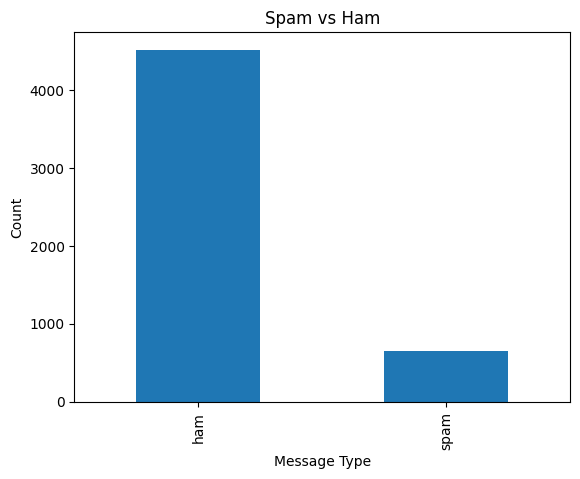

In [16]:
df['label'].value_counts().plot(kind='bar')

plt.title("Spam vs Ham")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

In [17]:
# Độ dài tin nhắn
df['message_length'] = df['message'].apply(len)

print(df.head())

# So sánh độ dài trung bình
print(df.groupby('label')['message_length'].mean())

  label                                            message  message_length
0   ham  Go until jurong point, crazy.. Available only ...             111
1   ham                      Ok lar... Joking wif u oni...              29
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...             155
3   ham  U dun say so early hor... U c already then say...              49
4   ham  Nah I don't think he goes to usf, he lives aro...              61
label
ham      70.459256
spam    137.891271
Name: message_length, dtype: float64


In [20]:
import ssl
import nltk

ssl._create_default_https_context = ssl._create_unverified_context

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [21]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize

In [22]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def transform_text(text):
    text = text.lower()
    text = word_tokenize(text)

    y = []

    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stop_words:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [23]:
print(transform_text("FREE entry!!! Win money now!!!"))

free entri win money


In [24]:
# preprocess toàn bộ dataset
df['processed_text'] = df['message'].apply(transform_text)

print(df[['message', 'processed_text']].head())

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                      processed_text  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri 2 wkli comp win fa cup final tkt 21...  
3                u dun say earli hor u c alreadi say  
4               nah think goe usf live around though  


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

In [27]:
X = df['processed_text'].values
y = df['label'].values

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
cv = CountVectorizer()

In [30]:
X_train = cv.fit_transform(X_train)
X_test = cv.transform(X_test)

In [31]:
print(X_train.shape)
print(X_test.shape)

(4135, 5936)
(1034, 5936)


In [32]:
print(cv.get_feature_names_out()[:20])

['008704050406' '0089' '0121' '01223585236' '01223585334' '0125698789'
 '02' '0207' '02073162414' '02085076972' '021' '050703' '0578'
 '07008009200' '07046744435' '07090201529' '07090298926' '07099833605'
 '07123456789' '0721072']


In [33]:
print(X_train[0].toarray())

[[0 0 0 ... 0 0 0]]


In [60]:
from wordcloud import WordCloud

import re
import string

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [61]:
STOP_WORDS = set(stopwords.words('english'))

def preprocess_text(text):

    # lowercase
    text = text.lower()

    # thay url
    text = re.sub(r'http\S+|www\S+', ' url ', text)

    # thay phone number
    text = re.sub(r'\b\d{10,}\b', ' phonenumber ', text)

    # xóa số
    text = re.sub(r'\d+', ' ', text)

    # xóa punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # tokenize
    tokens = word_tokenize(text)

    # remove stopwords + từ ngắn
    tokens = [
        t for t in tokens
        if t not in STOP_WORDS and len(t) > 2
    ]

    return ' '.join(tokens)

# tạo cột clean_message
df['clean_message'] = df['message'].apply(preprocess_text)

In [40]:
COLOR_HAM = 'green'
COLOR_SPAM = 'red'

OUTPUT_DIR = 'outputs'

In [ ]:
import os

# lấy thư mục hiện tại
CURRENT_DIR = os.getcwd()

# lùi lên 1 cấp khỏi src
BASE_DIR = os.path.dirname(CURRENT_DIR)

# trỏ tới report ngang hàng src
OUTPUT_DIR = os.path.join(BASE_DIR, 'report')

# tạo nếu chưa có
os.makedirs(OUTPUT_DIR, exist_ok=True)

# lưu ảnh
plt.savefig(
    os.path.join(OUTPUT_DIR, '02_wordcloud.png'),
    bbox_inches='tight'
)

Đã lưu vào: c:\Python\SMS_Spam_Project\report


<Figure size 640x480 with 0 Axes>

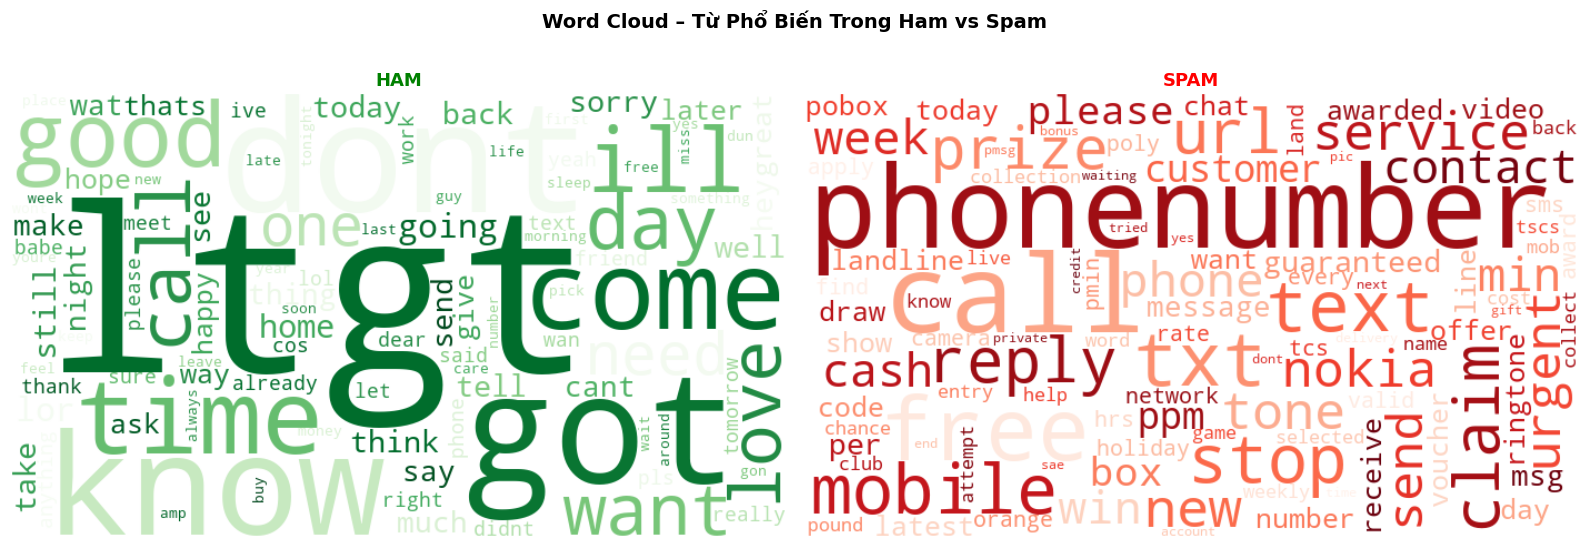

In [62]:
# =========================
# WORD CLOUD
# =========================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.suptitle(
    'Word Cloud – Từ Phổ Biến Trong Ham vs Spam',
    fontsize=14,
    fontweight='bold'
)

for ax, label, color in zip(
    axes,
    ['ham', 'spam'],
    [COLOR_HAM, COLOR_SPAM]
):

    text = ' '.join(
        df[df['label'] == label]['clean_message']
    )

    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap='Greens' if label == 'ham' else 'Reds',
                   max_words=100, collocations=False).generate(text)

    ax.imshow(wc, interpolation='bilinear')

    ax.axis('off')

    ax.set_title(
        f'HAM' if label == 'ham' else 'SPAM',
        fontsize=13,
        fontweight='bold',
        color=color
    )

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/02_wordcloud.png",
    bbox_inches='tight'
)

plt.show()

plt.close()